In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load dataset
df = pd.read_csv("ghg-emissions.csv")

# Display first rows
print(df.head())

# Check dataset structure
print(df.info())

# Check dataset shape
print("Dataset Shape:", df.shape)

  Country/Region    unit     1990     1991     1992     1993     1994  \
0          China  MtCO2e  2873.71  3023.38  3154.54  3377.79  3528.81   
1  United States  MtCO2e  5543.47  5501.92  5583.80  5691.26  5782.20   
2          India  MtCO2e  1009.44  1064.49  1096.71  1128.44  1174.78   
3         Russia  MtCO2e  2885.12  2788.70  2551.94  2294.62  2011.47   
4      Indonesia  MtCO2e  1257.10  1274.43  1295.01  1311.27  1327.87   

      1995     1996     1997  ...     2009     2010      2011      2012  \
0  3918.30  3954.75  3963.61  ...  9046.19  9872.37  10364.83  10690.04   
1  5843.90  6010.62  6258.47  ...  5793.66  6041.59   5796.78   5550.87   
2  1240.44  1289.63  1348.09  ...  2467.78  2576.93   2610.32   2758.53   
3  1930.88  1889.18  1755.59  ...  1575.54  1690.93   1864.86   1886.41   
4  1360.88  1179.00  2142.82  ...  1483.61  1125.25   1675.72   1695.27   

       2013      2014      2015      2016      2017      2018  
0  11144.76  11155.76  11149.68  11207.66  114

## Basic Data Inspection 

In [3]:
# Check missing values
print(df.isnull().sum())

# Check unique countries
print("Number of countries:", df['Country/Region'].nunique())

# Summary statistics
print(df.describe())

Country/Region    0
unit              0
1990              2
1991              2
1992              2
1993              2
1994              2
1995              2
1996              2
1997              2
1998              2
1999              2
2000              2
2001              2
2002              2
2003              2
2004              2
2005              2
2006              2
2007              2
2008              2
2009              2
2010              2
2011              2
2012              2
2013              2
2014              2
2015              2
2016              2
2017              2
2018              2
dtype: int64
Number of countries: 195
              1991         1992         1993         1994         1995  \
count   193.000000   193.000000   193.000000   193.000000   193.000000   
mean    165.380052   164.705233   165.176839   166.121917   169.715596   
std     531.798918   533.953728   540.662567   545.922424   562.294116   
min      -5.410000    -5.420000    -5.450000  

## Data Cleaning

In [4]:
# Drop unit column (not required for modeling)
df = df.drop(columns=['unit'])

# Rename column
df.rename(columns={'Country/Region':'Country'}, inplace=True)

print(df.head())

         Country     1990     1991     1992     1993     1994     1995  \
0          China  2873.71  3023.38  3154.54  3377.79  3528.81  3918.30   
1  United States  5543.47  5501.92  5583.80  5691.26  5782.20  5843.90   
2          India  1009.44  1064.49  1096.71  1128.44  1174.78  1240.44   
3         Russia  2885.12  2788.70  2551.94  2294.62  2011.47  1930.88   
4      Indonesia  1257.10  1274.43  1295.01  1311.27  1327.87  1360.88   

      1996     1997     1998  ...     2009     2010      2011      2012  \
0  3954.75  3963.61  4103.23  ...  9046.19  9872.37  10364.83  10690.04   
1  6010.62  6258.47  6293.80  ...  5793.66  6041.59   5796.78   5550.87   
2  1289.63  1348.09  1382.26  ...  2467.78  2576.93   2610.32   2758.53   
3  1889.18  1755.59  1740.23  ...  1575.54  1690.93   1864.86   1886.41   
4  1179.00  2142.82  1373.56  ...  1483.61  1125.25   1675.72   1695.27   

       2013      2014      2015      2016      2017      2018  
0  11144.76  11155.76  11149.68  11207.6

## Convert Data to Time-Series Format

In [5]:
df_long = df.melt(id_vars=['Country'],
                  var_name='Year',
                  value_name='Emissions')

df_long['Year'] = df_long['Year'].astype(int)

print(df_long.head())

         Country  Year Emissions
0          China  1990   2873.71
1  United States  1990   5543.47
2          India  1990   1009.44
3         Russia  1990   2885.12
4      Indonesia  1990   1257.10


## Exploratory Data Analysis (EDA)

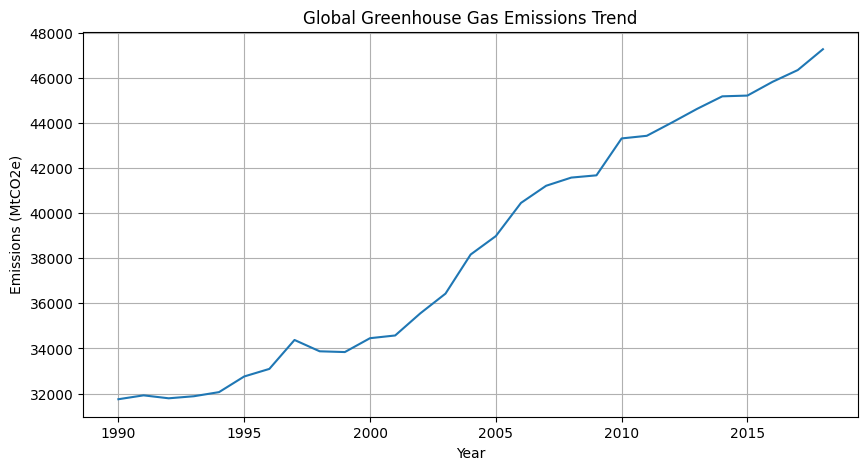

In [6]:
# Convert emissions column to numeric
df_long['Emissions'] = pd.to_numeric(df_long['Emissions'], errors='coerce')

# Remove missing values created during conversion
df_long = df_long.dropna(subset=['Emissions'])

# Now compute global trend
global_trend = df_long.groupby('Year')['Emissions'].sum()

# Plot
plt.figure(figsize=(10,5))
plt.plot(global_trend.index, global_trend.values)

plt.title("Global Greenhouse Gas Emissions Trend")
plt.xlabel("Year")
plt.ylabel("Emissions (MtCO2e)")
plt.grid(True)

plt.show()

In [7]:
# Convert emissions column to numeric
df_long['Emissions'] = pd.to_numeric(df_long['Emissions'], errors='coerce')

# Remove invalid rows
df_long = df_long.dropna(subset=['Emissions'])

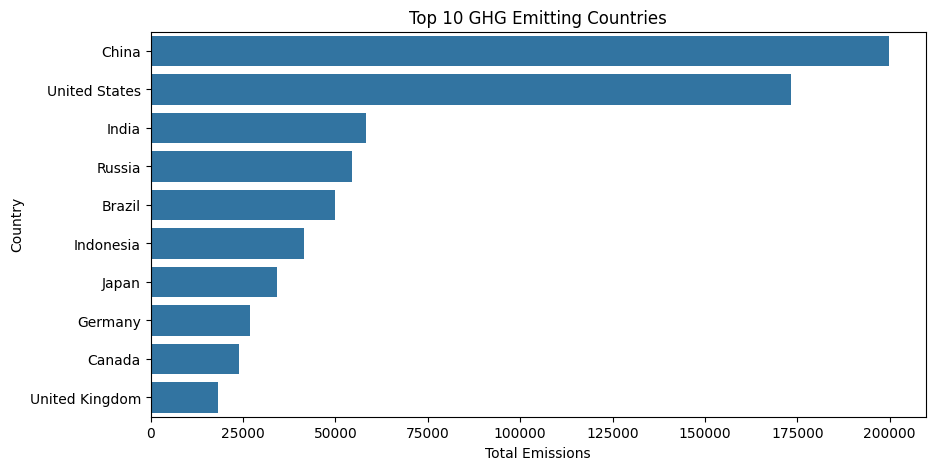

In [8]:
top_countries = df_long.groupby('Country')['Emissions'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 GHG Emitting Countries")
plt.xlabel("Total Emissions")
plt.ylabel("Country")
plt.show()

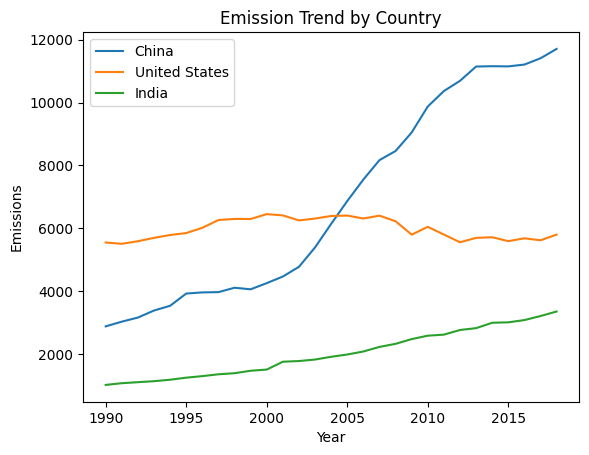

In [9]:
countries = ["China","United States","India"]

for c in countries:
    data = df_long[df_long['Country']==c]
    
    plt.plot(data['Year'], data['Emissions'], label=c)

plt.title("Emission Trend by Country")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.legend()
plt.show()

In [10]:
# Drop country column
df_years = df.drop(columns=['Country'])

# Convert all columns to numeric
df_years = df_years.apply(pd.to_numeric, errors='coerce')

In [11]:
df_years = df_years.dropna(axis=1, how='all')

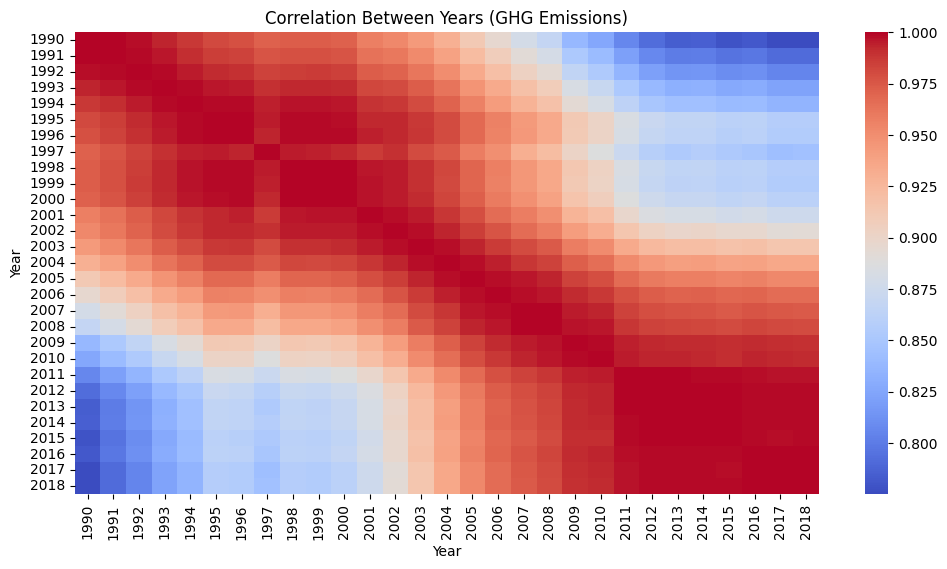

In [12]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df_years.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Between Years (GHG Emissions)")
plt.xlabel("Year")
plt.ylabel("Year")

plt.show()

## Baseline models

In [29]:

df = pd.read_csv("ghg-emissions.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nDataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of countries:", df['Country/Region'].nunique())

# %%
# -------------------------
# 2. Basic cleaning
# -------------------------
df = df.drop(columns=['unit'])
df.rename(columns={'Country/Region': 'Country'}, inplace=True)

print("\nCleaned dataframe:")
print(df.head())

First 5 rows:
  Country/Region    unit     1990     1991     1992     1993     1994  \
0          China  MtCO2e  2873.71  3023.38  3154.54  3377.79  3528.81   
1  United States  MtCO2e  5543.47  5501.92  5583.80  5691.26  5782.20   
2          India  MtCO2e  1009.44  1064.49  1096.71  1128.44  1174.78   
3         Russia  MtCO2e  2885.12  2788.70  2551.94  2294.62  2011.47   
4      Indonesia  MtCO2e  1257.10  1274.43  1295.01  1311.27  1327.87   

      1995     1996     1997  ...     2009     2010      2011      2012  \
0  3918.30  3954.75  3963.61  ...  9046.19  9872.37  10364.83  10690.04   
1  5843.90  6010.62  6258.47  ...  5793.66  6041.59   5796.78   5550.87   
2  1240.44  1289.63  1348.09  ...  2467.78  2576.93   2610.32   2758.53   
3  1930.88  1889.18  1755.59  ...  1575.54  1690.93   1864.86   1886.41   
4  1360.88  1179.00  2142.82  ...  1483.61  1125.25   1675.72   1695.27   

       2013      2014      2015      2016      2017      2018  
0  11144.76  11155.76  11149.68 


Long format sample:
         Country  Year  Emissions
0          China  1990    2873.71
1  United States  1990    5543.47
2          India  1990    1009.44
3         Russia  1990    2885.12
4      Indonesia  1990    1257.10


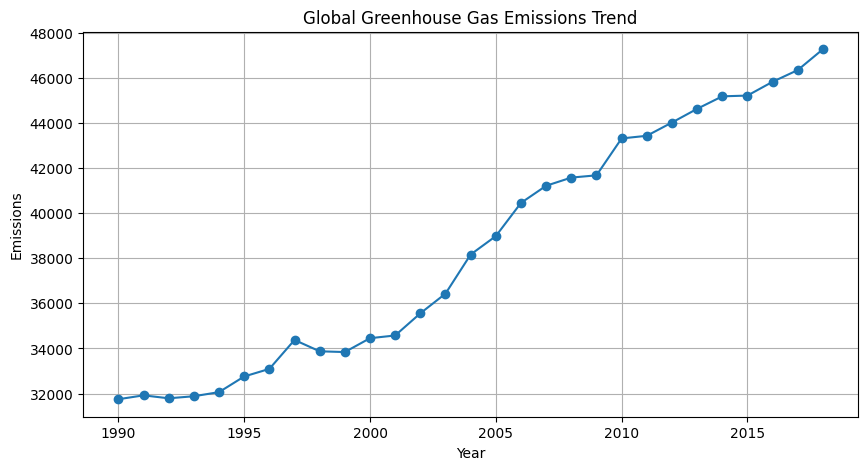

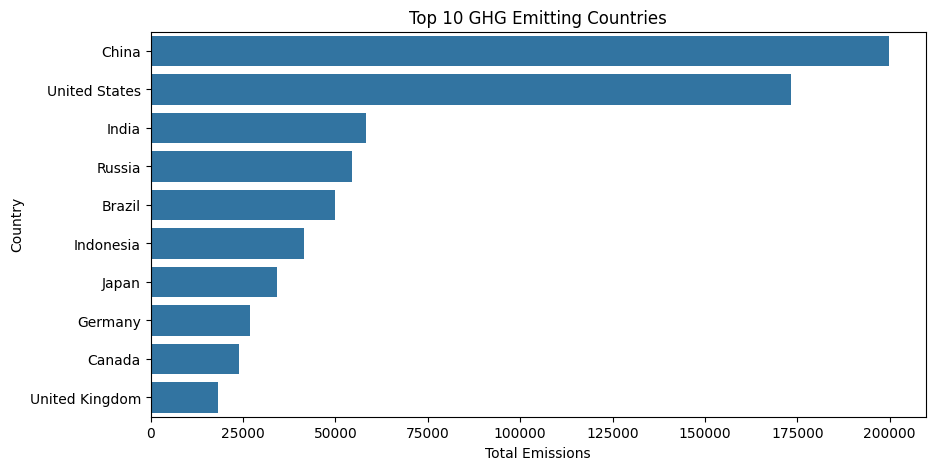

In [30]:
# %%
# -------------------------
# 3. Convert to long format
# -------------------------
df_long = df.melt(
    id_vars=['Country'],
    var_name='Year',
    value_name='Emissions'
)

df_long['Year'] = pd.to_numeric(df_long['Year'], errors='coerce')
df_long['Emissions'] = pd.to_numeric(df_long['Emissions'], errors='coerce')

df_long = df_long.dropna(subset=['Year', 'Emissions'])
df_long['Year'] = df_long['Year'].astype(int)

print("\nLong format sample:")
print(df_long.head())

# %%
# -------------------------
# 4. Optional EDA
# -------------------------
global_trend = df_long.groupby('Year')['Emissions'].sum()

plt.figure(figsize=(10, 5))
plt.plot(global_trend.index, global_trend.values, marker='o')
plt.title("Global Greenhouse Gas Emissions Trend")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.grid(True)
plt.show()

# %%
top_countries = df_long.groupby('Country')['Emissions'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 GHG Emitting Countries")
plt.xlabel("Total Emissions")
plt.ylabel("Country")
plt.show()

# %%
# -------------------------
# 5. Select one country
# -------------------------

In [31]:
selected_country = "China"   # Change this to any country you want


Selected country: China
   Year  Emissions
0  1990    2873.71
1  1991    3023.38
2  1992    3154.54
3  1993    3377.79
4  1994    3528.81
    Year  Emissions
24  2014   11155.76
25  2015   11149.68
26  2016   11207.66
27  2017   11408.26
28  2018   11705.81


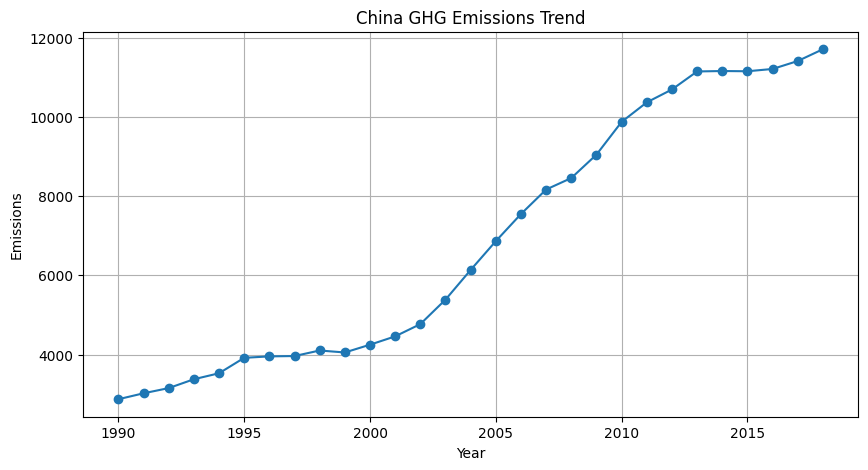


Train years: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013]
Test years : [2014, 2015, 2016, 2017, 2018]

Feature dataframe:
   Year  Emissions  Log_Emissions  Scaled_Log_Emissions     lag_1     lag_2  \
0  1993    3377.79       8.125273              0.119227  0.068783  0.037454   
1  1994    3528.81       8.168999              0.151495  0.119227  0.068783   
2  1995    3918.30       8.273668              0.228736  0.151495  0.119227   
3  1996    3954.75       8.282925              0.235567  0.228736  0.151495   
4  1997    3963.61       8.285163              0.237218  0.235567  0.228736   

      lag_3  rolling_mean_3  rolling_std_3    diff_1  year_index  
0  0.000000        0.035412       0.034437  0.050445           3  
1  0.037454        0.075155       0.041257  0.032268           4  
2  0.068783        0.113168       0.041688  0.077240           5  
3  0.119227        0.166486       

In [40]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from xgboost import XGBRegressor

country_df = df_long[df_long['Country'] == selected_country].copy()
country_df = country_df.groupby('Year', as_index=False)['Emissions'].sum()
country_df = country_df.sort_values('Year').reset_index(drop=True)

print(f"\nSelected country: {selected_country}")
print(country_df.head())
print(country_df.tail())

# %%
plt.figure(figsize=(10, 5))
plt.plot(country_df['Year'], country_df['Emissions'], marker='o')
plt.title(f"{selected_country} GHG Emissions Trend")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.grid(True)
plt.show()

# %%
# -------------------------
# 6. Parameters
# -------------------------
test_size = 5
n_lags = 3

if len(country_df) <= test_size + n_lags + 3:
    raise ValueError("Not enough observations for the chosen country. Try a country with more years.")

# %%
# -------------------------
# 7. Log transform
# -------------------------
country_df['Log_Emissions'] = np.log1p(country_df['Emissions'])

# %%
# -------------------------
# 8. Split train and test
# -------------------------
train_raw = country_df.iloc[:-test_size].copy()
test_raw = country_df.iloc[-test_size:].copy()

print("\nTrain years:", train_raw['Year'].tolist())
print("Test years :", test_raw['Year'].tolist())

# %%
# -------------------------
# 9. Scale only on training data
# -------------------------
scaler = MinMaxScaler()

train_raw['Scaled_Log_Emissions'] = scaler.fit_transform(train_raw[['Log_Emissions']])
test_raw['Scaled_Log_Emissions'] = scaler.transform(test_raw[['Log_Emissions']])

all_scaled = pd.concat([train_raw, test_raw], axis=0).reset_index(drop=True)

# %%
# -------------------------
# 10. Create lag features
# -------------------------
def create_features(data, target_col, n_lags=3):
    df_feat = data.copy()

    for lag in range(1, n_lags + 1):
        df_feat[f'lag_{lag}'] = df_feat[target_col].shift(lag)

    df_feat['rolling_mean_3'] = df_feat[target_col].shift(1).rolling(3).mean()
    df_feat['rolling_std_3'] = df_feat[target_col].shift(1).rolling(3).std()
    df_feat['diff_1'] = df_feat[target_col].diff()
    df_feat['year_index'] = np.arange(len(df_feat))

    df_feat = df_feat.dropna().reset_index(drop=True)
    return df_feat

feature_df = create_features(all_scaled, 'Scaled_Log_Emissions', n_lags=n_lags)

print("\nFeature dataframe:")
print(feature_df.head())

# %%
# -------------------------
# 11. Train-test split after feature creation
# -------------------------
first_test_year = test_raw['Year'].min()

train_df = feature_df[feature_df['Year'] < first_test_year].copy()
test_df = feature_df[feature_df['Year'] >= first_test_year].copy()

feature_cols = [f'lag_{i}' for i in range(1, n_lags + 1)] + [
    'rolling_mean_3', 'rolling_std_3', 'diff_1', 'year_index'
]

X_train = train_df[feature_cols]
y_train = train_df['Scaled_Log_Emissions']

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(test_df))

# %%
# -------------------------
# 12. Train ML models
# -------------------------
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
rf_model.fit(X_train, y_train)

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)
xgb_model.fit(X_train, y_train)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# %%
# -------------------------
# 13. Walk-forward prediction using actual updates
# -------------------------
def walk_forward_ml_actual_updates(model, train_scaled_values, test_scaled_values, n_lags):
    history = train_scaled_values.copy()
    predictions = []

    for actual in test_scaled_values:
        lag_vals = history[-n_lags:]
        rolling_mean_3 = np.mean(history[-3:])
        rolling_std_3 = np.std(history[-3:], ddof=1) if len(history[-3:]) > 1 else 0.0
        diff_1 = history[-1] - history[-2] if len(history) >= 2 else 0.0
        year_index = len(history)

        x_input = np.array(lag_vals + [rolling_mean_3, rolling_std_3, diff_1, year_index]).reshape(1, -1)

        pred = model.predict(x_input)[0]
        predictions.append(pred)

        # use actual observed value for fair test-time evaluation
        history.append(actual)

    return predictions

train_scaled_values = train_raw['Scaled_Log_Emissions'].tolist()
test_scaled_values = test_raw['Scaled_Log_Emissions'].tolist()
test_years = test_raw['Year'].tolist()

rf_pred_scaled = walk_forward_ml_actual_updates(rf_model, train_scaled_values, test_scaled_values, n_lags)
xgb_pred_scaled = walk_forward_ml_actual_updates(xgb_model, train_scaled_values, test_scaled_values, n_lags)
lr_pred_scaled = walk_forward_ml_actual_updates(lr_model, train_scaled_values, test_scaled_values, n_lags)

# %%
# -------------------------
# 14. Naive baseline
# -------------------------
naive_preds_log = []
history_naive = train_raw['Log_Emissions'].tolist()

for actual in test_raw['Log_Emissions'].tolist():
    pred = history_naive[-1]
    naive_preds_log.append(pred)
    history_naive.append(actual)

# %%
# -------------------------
# 15. ARIMA order search
# -------------------------
def arima_walk_forward(train_series, test_series, order):
    history = list(train_series)
    preds = []

    for actual in test_series:
        model = ARIMA(
            history,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit()
        forecast = fitted.forecast(steps=1)[0]
        preds.append(forecast)
        history.append(actual)

    return preds

train_series_log = train_raw['Log_Emissions'].values
test_series_log = test_raw['Log_Emissions'].values

best_arima_order = None
best_arima_mse = np.inf
best_arima_preds = None

for p in [0, 1, 2]:
    for d in [0, 1]:
        for q in [0, 1, 2]:
            try:
                preds = arima_walk_forward(train_series_log, test_series_log, (p, d, q))
                mse = mean_squared_error(test_series_log, preds)

                if mse < best_arima_mse:
                    best_arima_mse = mse
                    best_arima_order = (p, d, q)
                    best_arima_preds = preds
            except:
                continue

print("\nBest ARIMA order:", best_arima_order)
print("Best ARIMA MSE on log scale:", best_arima_mse)

# %%
# -------------------------
# 16. Exponential Smoothing
# -------------------------
history_es = train_raw['Log_Emissions'].tolist()
es_preds_log = []

for actual in test_raw['Log_Emissions'].tolist():
    try:
        es_model = ExponentialSmoothing(
            history_es,
            trend='add',
            seasonal=None,
            damped_trend=True
        )
        es_fit = es_model.fit(optimized=True)
        forecast = es_fit.forecast(1)[0]
    except:
        forecast = history_es[-1]

    es_preds_log.append(forecast)
    history_es.append(actual)

# %%
# -------------------------
# 17. Convert predictions back to original scale
# -------------------------
actual_log = test_raw['Log_Emissions'].values

rf_pred_log = scaler.inverse_transform(np.array(rf_pred_scaled).reshape(-1, 1)).flatten()
xgb_pred_log = scaler.inverse_transform(np.array(xgb_pred_scaled).reshape(-1, 1)).flatten()
lr_pred_log = scaler.inverse_transform(np.array(lr_pred_scaled).reshape(-1, 1)).flatten()
arima_pred_log = np.array(best_arima_preds)
naive_pred_log = np.array(naive_preds_log)
es_pred_log = np.array(es_preds_log)

actual_actual = np.expm1(actual_log)
rf_pred_actual = np.expm1(rf_pred_log)
xgb_pred_actual = np.expm1(xgb_pred_log)
lr_pred_actual = np.expm1(lr_pred_log)
arima_pred_actual = np.expm1(arima_pred_log)
naive_pred_actual = np.expm1(naive_pred_log)
es_pred_actual = np.expm1(es_pred_log)

# %%
# -------------------------
# 18. Evaluation
# -------------------------
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance")
    print("MAE  :", mae)
    print("MSE  :", mse)
    print("RMSE :", rmse)
    print("R2   :", r2)

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

naive_metrics = evaluate_model(actual_actual, naive_pred_actual, "Naive Baseline")
rf_metrics = evaluate_model(actual_actual, rf_pred_actual, "Random Forest")
xgb_metrics = evaluate_model(actual_actual, xgb_pred_actual, "XGBoost")
lr_metrics = evaluate_model(actual_actual, lr_pred_actual, "Linear Regression")
arima_metrics = evaluate_model(actual_actual, arima_pred_actual, f"ARIMA{best_arima_order}")
es_metrics = evaluate_model(actual_actual, es_pred_actual, "Exponential Smoothing")

metrics_df = pd.DataFrame([
    naive_metrics,
    rf_metrics,
    xgb_metrics,
    lr_metrics,
    arima_metrics,
    es_metrics
])

print("\nModel comparison:")
print(metrics_df.sort_values('RMSE'))

# %%
# -------------------------
# 19. Detailed results table
# -------------------------
results_df = pd.DataFrame({
    'Year': test_years,
    'Actual_Emissions': actual_actual,
    'Naive_Predicted': naive_pred_actual,
    'RF_Predicted': rf_pred_actual,
    'XGB_Predicted': xgb_pred_actual,
    'LR_Predicted': lr_pred_actual,
    'ARIMA_Predicted': arima_pred_actual,
    'ES_Predicted': es_pred_actual
})

print("\nDetailed predictions:")
print(results_df)

# %%
# -------------------------
# 20. Plot actual vs predicted
# -------------------------



Selected country: China
   Year  Emissions
0  1990    2873.71
1  1991    3023.38
2  1992    3154.54
3  1993    3377.79
4  1994    3528.81
    Year  Emissions
24  2014   11155.76
25  2015   11149.68
26  2016   11207.66
27  2017   11408.26
28  2018   11705.81


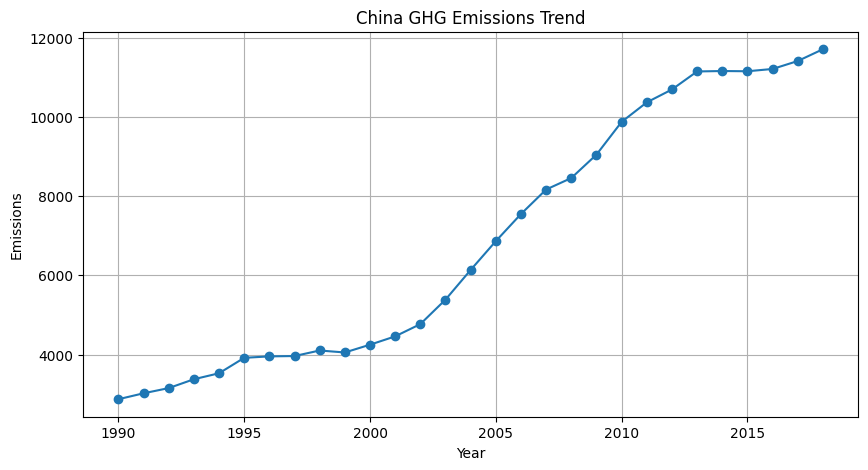


Train years: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013]
Test years : [2014, 2015, 2016, 2017, 2018]

Sub-train years: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010]
Validation years: [2011, 2012, 2013]
Config: {'n_steps': 2, 'units': 8, 'dropout_rate': 0.1}  --> Validation RMSE: 271.8583
Config: {'n_steps': 2, 'units': 16, 'dropout_rate': 0.2}  --> Validation RMSE: 1129.9348
Config: {'n_steps': 3, 'units': 8, 'dropout_rate': 0.1}  --> Validation RMSE: 105.1314
Config: {'n_steps': 3, 'units': 16, 'dropout_rate': 0.2}  --> Validation RMSE: 508.1914
Config: {'n_steps': 4, 'units': 8, 'dropout_rate': 0.2}  --> Validation RMSE: 507.0591

Best configuration: {'n_steps': 3, 'units': 8, 'dropout_rate': 0.1}
Best validation RMSE: 105.13138438621327

Final model trained.


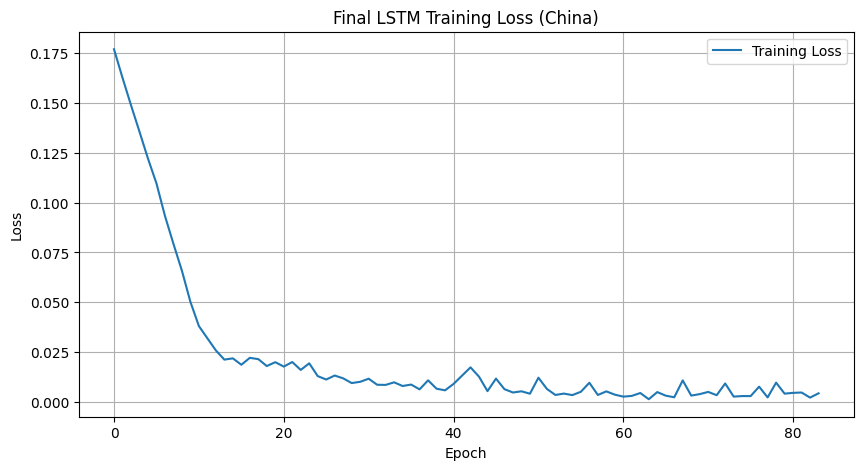


Detailed predictions:
   Year  Actual_Emissions  Predicted_Emissions  Absolute_Error  Squared_Error  \
0  2014          11155.76         11036.200195      119.559805   14294.546897   
1  2015          11149.68         11235.411133       85.731133    7349.827133   
2  2016          11207.66         11359.419922      151.759922   23031.073888   
3  2017          11408.26         11374.695312       33.564688    1126.588247   
4  2018          11705.81         11433.341797      272.468203   74238.921714   

   Percentage_Error  
0          1.071732  
1          0.768911  
2          1.354073  
3          0.294214  
4          2.327632  

Improved LSTM Performance for China
MAE  : 132.61674999999667
MSE  : 24008.191575773577
RMSE : 154.94576978986416
R2   : 0.46671097733439537


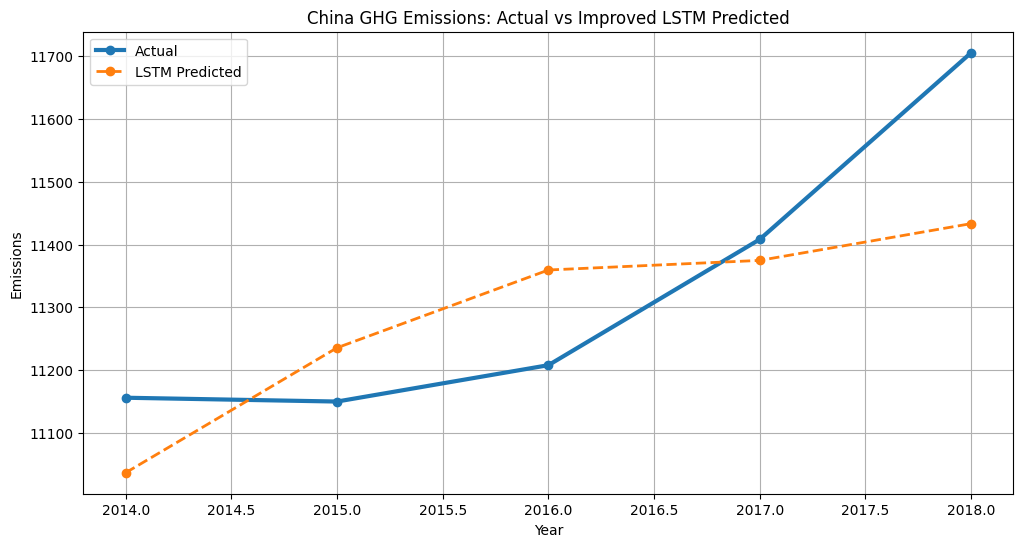

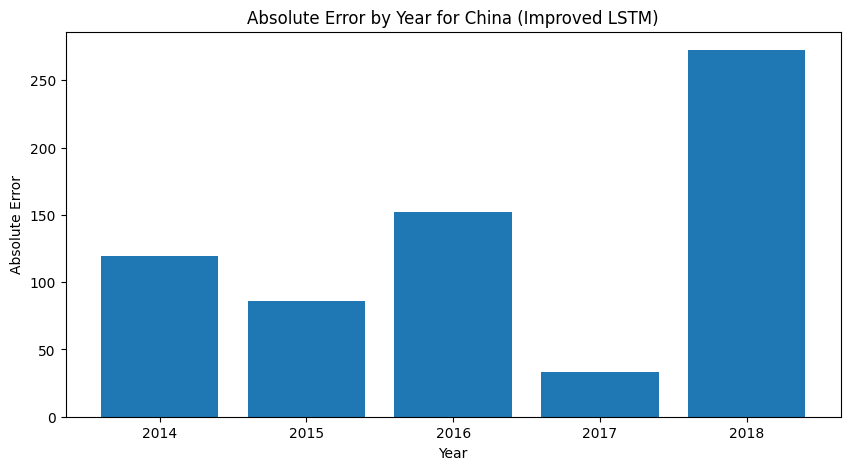


Future 5-Year Forecast:
   Year  Forecasted_Emissions
0  2019          11562.522461
1  2020          11648.271484
2  2021          11713.265625
3  2022          11710.428711
4  2023          11746.067383


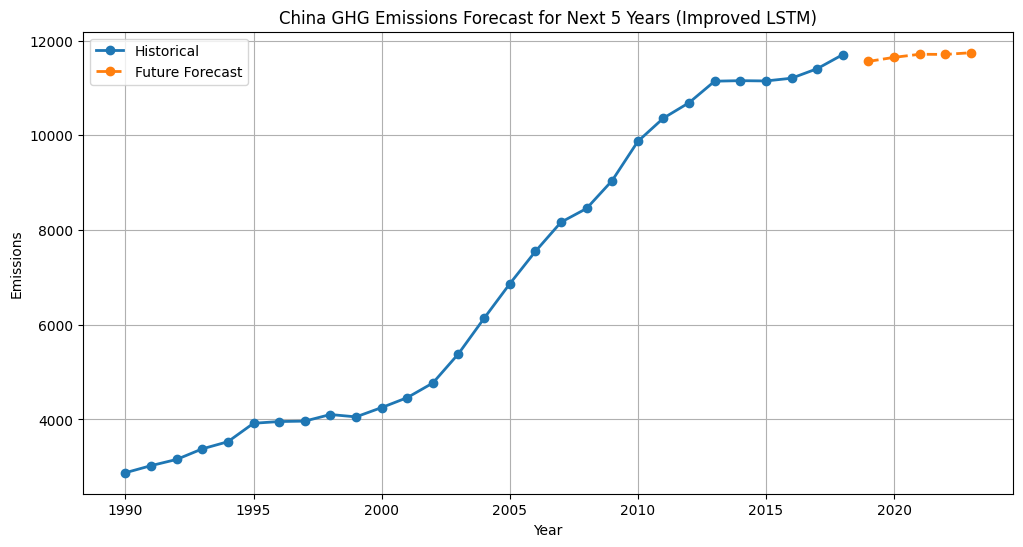

In [34]:


import warnings
warnings.filterwarnings("ignore")

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)




country_df = df_long[df_long["Country"] == selected_country].copy()
country_df = country_df.groupby("Year", as_index=False)["Emissions"].sum()
country_df = country_df.sort_values("Year").reset_index(drop=True)

print(f"\nSelected country: {selected_country}")
print(country_df.head())
print(country_df.tail())

# %%
# -------------------------
# 6. Plot selected country
# -------------------------
plt.figure(figsize=(10, 5))
plt.plot(country_df["Year"], country_df["Emissions"], marker="o")
plt.title(f"{selected_country} GHG Emissions Trend")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.grid(True)
plt.show()

# %%
# -------------------------
# 7. Parameters
# -------------------------
test_size = 5
val_size = 3   # taken from tail of training period for chronological validation

if len(country_df) < 15:
    raise ValueError("Too few observations for LSTM. Choose a country with more annual records.")

# %%
# -------------------------
# 8. Log transform
# -------------------------
country_df["Log_Emissions"] = np.log1p(country_df["Emissions"])

# %%
# -------------------------
# 9. Train / test split
# -------------------------
train_full = country_df.iloc[:-test_size].copy()
test_df = country_df.iloc[-test_size:].copy()

print("\nTrain years:", train_full["Year"].tolist())
print("Test years :", test_df["Year"].tolist())

if len(train_full) <= val_size + 3:
    raise ValueError("Training set too small after split. Reduce val_size or choose another country.")

# %%
# -------------------------
# 10. Train / validation split (chronological)
# -------------------------
train_sub = train_full.iloc[:-val_size].copy()
val_df = train_full.iloc[-val_size:].copy()

print("\nSub-train years:", train_sub["Year"].tolist())
print("Validation years:", val_df["Year"].tolist())

# %%
# -------------------------
# 11. Scale using sub-train only
# -------------------------
scaler = MinMaxScaler()

train_sub["Scaled_Log"] = scaler.fit_transform(train_sub[["Log_Emissions"]])
val_df["Scaled_Log"] = scaler.transform(val_df[["Log_Emissions"]])
train_full["Scaled_Log"] = scaler.transform(train_full[["Log_Emissions"]])
test_df["Scaled_Log"] = scaler.transform(test_df[["Log_Emissions"]])

# %%
# -------------------------
# 12. Sequence creation
# -------------------------
def create_sequences(values, n_steps):
    X, y = [], []
    for i in range(n_steps, len(values)):
        X.append(values[i - n_steps:i])
        y.append(values[i])
    return np.array(X), np.array(y)

def build_train_val_sequences(train_values, val_values, n_steps):
    """
    For validation, prepend the last n_steps of training values
    so validation windows are formed correctly in chronological order.
    """
    X_train, y_train = create_sequences(train_values, n_steps)

    combined_for_val = np.concatenate([train_values[-n_steps:], val_values])
    X_val, y_val = create_sequences(combined_for_val, n_steps)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

    return X_train, y_train, X_val, y_val

# %%
# -------------------------
# 13. Build improved small LSTM
# -------------------------
def build_lstm_model(n_steps, units=16, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(n_steps, 1)),
        LSTM(
            units,
            activation="tanh",
            recurrent_activation="sigmoid",
            dropout=dropout_rate,
            recurrent_dropout=dropout_rate
        ),
        Dense(8, activation="relu"),
        Dense(1)
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber())
    return model

# %%
# -------------------------
# 14. Tune a few settings on validation set
# -------------------------
search_space = [
    {"n_steps": 2, "units": 8,  "dropout_rate": 0.1},
    {"n_steps": 2, "units": 16, "dropout_rate": 0.2},
    {"n_steps": 3, "units": 8,  "dropout_rate": 0.1},
    {"n_steps": 3, "units": 16, "dropout_rate": 0.2},
    {"n_steps": 4, "units": 8,  "dropout_rate": 0.2},
]

best_config = None
best_val_rmse = np.inf
best_history = None

train_sub_values = train_sub["Scaled_Log"].values
val_values = val_df["Scaled_Log"].values

for cfg in search_space:
    n_steps = cfg["n_steps"]

    if len(train_sub_values) <= n_steps:
        continue

    X_train, y_train, X_val, y_val = build_train_val_sequences(
        train_sub_values, val_values, n_steps
    )

    model = build_lstm_model(
        n_steps=n_steps,
        units=cfg["units"],
        dropout_rate=cfg["dropout_rate"],
        learning_rate=0.001
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=8,
            min_lr=1e-5
        )
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=250,
        batch_size=2,
        shuffle=False,
        verbose=0,
        callbacks=callbacks
    )

    val_pred = model.predict(X_val, verbose=0).flatten()
    val_pred_log = scaler.inverse_transform(val_pred.reshape(-1, 1)).flatten()
    y_val_log = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()

    val_pred_actual = np.expm1(val_pred_log)
    y_val_actual = np.expm1(y_val_log)

    val_rmse = np.sqrt(mean_squared_error(y_val_actual, val_pred_actual))

    print(f"Config: {cfg}  --> Validation RMSE: {val_rmse:.4f}")

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_config = cfg
        best_history = history.history

print("\nBest configuration:", best_config)
print("Best validation RMSE:", best_val_rmse)

# %%
# -------------------------
# 15. Refit best LSTM on full training period
# -------------------------
best_n_steps = best_config["n_steps"]
best_units = best_config["units"]
best_dropout = best_config["dropout_rate"]

# refit scaler on FULL training data (train_full only)
final_scaler = MinMaxScaler()
train_full["Scaled_Log_Final"] = final_scaler.fit_transform(train_full[["Log_Emissions"]])
test_df["Scaled_Log_Final"] = final_scaler.transform(test_df[["Log_Emissions"]])

train_full_values = train_full["Scaled_Log_Final"].values
X_final_train, y_final_train = create_sequences(train_full_values, best_n_steps)
X_final_train = X_final_train.reshape((X_final_train.shape[0], X_final_train.shape[1], 1))

final_model = build_lstm_model(
    n_steps=best_n_steps,
    units=best_units,
    dropout_rate=best_dropout,
    learning_rate=0.001
)

final_callbacks = [
    EarlyStopping(
        monitor="loss",
        patience=20,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="loss",
        factor=0.5,
        patience=8,
        min_lr=1e-5
    )
]

final_history = final_model.fit(
    X_final_train,
    y_final_train,
    epochs=250,
    batch_size=2,
    shuffle=False,
    verbose=0,
    callbacks=final_callbacks
)

print("\nFinal model trained.")

# %%
# -------------------------
# 16. Plot final training loss
# -------------------------
plt.figure(figsize=(10, 5))
plt.plot(final_history.history["loss"], label="Training Loss")
plt.title(f"Final LSTM Training Loss ({selected_country})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# %%
# -------------------------
# 17. Walk-forward test prediction with actual updates
# -------------------------
history_scaled = train_full["Scaled_Log_Final"].tolist()
test_scaled = test_df["Scaled_Log_Final"].tolist()
test_years = test_df["Year"].tolist()

predictions_scaled = []

for actual_value in test_scaled:
    x_input = np.array(history_scaled[-best_n_steps:]).reshape(1, best_n_steps, 1)
    pred_scaled = final_model.predict(x_input, verbose=0)[0][0]
    predictions_scaled.append(pred_scaled)

    # use actual observed value for one-step-ahead evaluation
    history_scaled.append(actual_value)

# %%
# -------------------------
# 18. Inverse transform
# -------------------------
pred_log = final_scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
actual_log = test_df["Log_Emissions"].values

pred_actual = np.expm1(pred_log)
actual_actual = np.expm1(actual_log)

# %%
# -------------------------
# 19. Results table
# -------------------------
results_df = pd.DataFrame({
    "Year": test_years,
    "Actual_Emissions": actual_actual,
    "Predicted_Emissions": pred_actual
})

results_df["Absolute_Error"] = np.abs(results_df["Actual_Emissions"] - results_df["Predicted_Emissions"])
results_df["Squared_Error"] = (results_df["Actual_Emissions"] - results_df["Predicted_Emissions"]) ** 2
results_df["Percentage_Error"] = (
    np.abs(results_df["Actual_Emissions"] - results_df["Predicted_Emissions"]) /
    results_df["Actual_Emissions"]
) * 100

print("\nDetailed predictions:")
print(results_df)

# %%
# -------------------------
# 20. Evaluation metrics
# -------------------------
mae = mean_absolute_error(actual_actual, pred_actual)
mse = mean_squared_error(actual_actual, pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(actual_actual, pred_actual)

print(f"\nImproved LSTM Performance for {selected_country}")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)

# %%
# -------------------------
# 21. Plot actual vs predicted
# -------------------------
plt.figure(figsize=(12, 6))
plt.plot(results_df["Year"], results_df["Actual_Emissions"], marker="o", linewidth=3, label="Actual")
plt.plot(results_df["Year"], results_df["Predicted_Emissions"], marker="o", linestyle="--", linewidth=2, label="LSTM Predicted")

plt.title(f"{selected_country} GHG Emissions: Actual vs Improved LSTM Predicted")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.legend()
plt.grid(True)
plt.show()

# %%
# -------------------------
# 22. Error plot
# -------------------------
plt.figure(figsize=(10, 5))
plt.bar(results_df["Year"].astype(str), results_df["Absolute_Error"])
plt.title(f"Absolute Error by Year for {selected_country} (Improved LSTM)")
plt.xlabel("Year")
plt.ylabel("Absolute Error")
plt.show()

# %%
# -------------------------
# 23. Future 5-year forecast
# -------------------------
future_steps = 5
future_history_scaled = train_full["Scaled_Log_Final"].tolist() + test_df["Scaled_Log_Final"].tolist()

future_predictions_scaled = []
future_years = []

last_year = country_df["Year"].max()

for i in range(future_steps):
    x_input = np.array(future_history_scaled[-best_n_steps:]).reshape(1, best_n_steps, 1)
    next_pred_scaled = final_model.predict(x_input, verbose=0)[0][0]

    future_predictions_scaled.append(next_pred_scaled)
    future_history_scaled.append(next_pred_scaled)
    future_years.append(last_year + i + 1)

future_pred_log = final_scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1)).flatten()
future_pred_actual = np.expm1(future_pred_log)

future_df = pd.DataFrame({
    "Year": future_years,
    "Forecasted_Emissions": future_pred_actual
})

print("\nFuture 5-Year Forecast:")
print(future_df)

# %%
# -------------------------
# 24. Plot historical + future forecast
# -------------------------
plt.figure(figsize=(12, 6))
plt.plot(country_df["Year"], country_df["Emissions"], marker="o", linewidth=2, label="Historical")
plt.plot(future_df["Year"], future_df["Forecasted_Emissions"], marker="o", linestyle="--", linewidth=2, label="Future Forecast")

plt.title(f"{selected_country} GHG Emissions Forecast for Next 5 Years (Improved LSTM)")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
# %%
# Add LSTM metrics
lstm_metrics = {
    'Model': 'LSTM',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2
}

# Append to metrics dataframe
metrics_df = pd.concat([metrics_df, pd.DataFrame([lstm_metrics])], ignore_index=True)

print(metrics_df.sort_values('RMSE'))

                   Model         MAE            MSE        RMSE        R2
6                   LSTM  132.616750       0.000442  154.945770  0.466711
0         Naive Baseline  114.642000   26459.201860  162.662847  0.412267
4         ARIMA(0, 1, 0)  114.642000   26459.201860  162.662847  0.412267
5  Exponential Smoothing  181.668214   42994.296314  207.350660  0.044977
3      Linear Regression  283.832184   98786.767552  314.303623 -1.194330
2                XGBoost  278.422672  108426.586050  329.281925 -1.408457
1          Random Forest  537.287813  333006.634979  577.067271 -6.397008


In [42]:
# %%
# Add LSTM predictions to results dataframe
results_df['LSTM_Predicted'] = pred_actual

print(results_df)

   Year  Actual_Emissions  Naive_Predicted  RF_Predicted  XGB_Predicted  \
0  2014          11155.76         11144.76  10779.799900   10788.793945   
1  2015          11149.68         11155.76  10790.232758   11069.977539   
2  2016          11207.66         11149.68  10790.232758   11090.658203   
3  2017          11408.26         11207.66  10790.232758   11142.813477   
4  2018          11705.81         11408.26  10790.232758   11142.813477   

   LR_Predicted  ARIMA_Predicted  ES_Predicted  LSTM_Predicted  
0  10805.717904         11144.76  11518.194437    11036.200195  
1  10700.591227         11155.76  11292.745074    11235.411133  
2  11138.685995         11149.68  11150.478233    11359.419922  
3  11213.771614         11207.66  11227.212896    11374.695312  
4  11349.242339         11408.26  11541.197314    11433.341797  


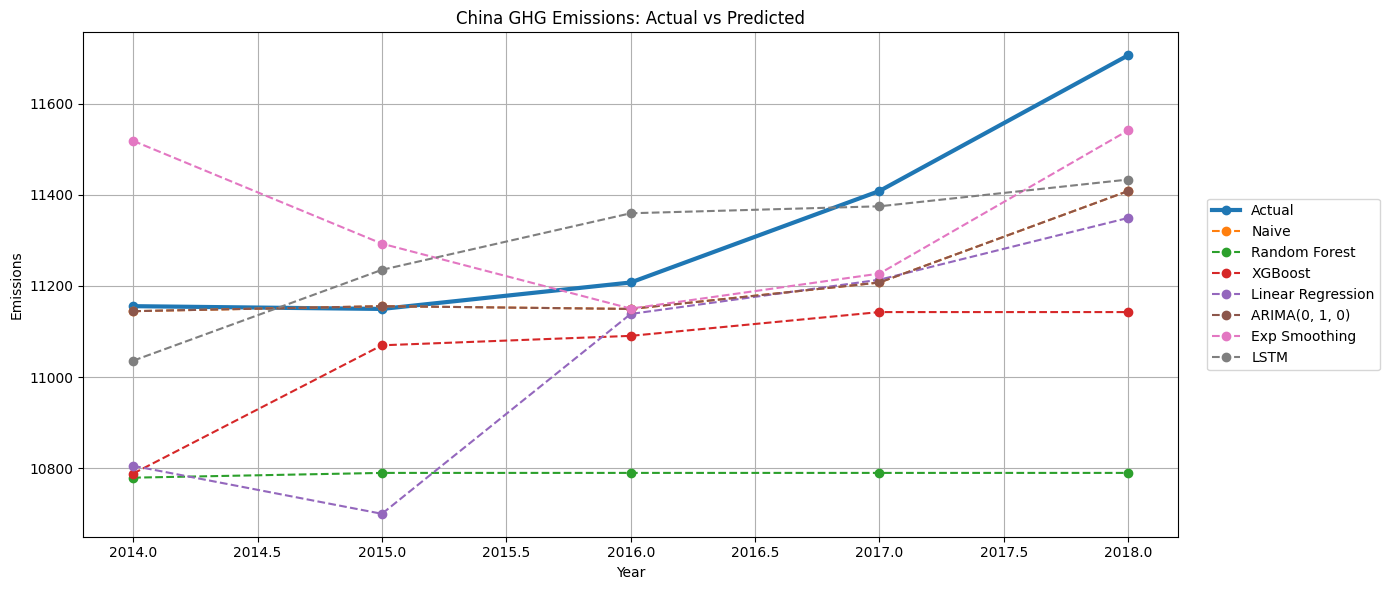

In [47]:
# %%
plt.figure(figsize=(14, 6))

plt.plot(results_df['Year'], results_df['Actual_Emissions'], marker='o', linewidth=3, label='Actual')
plt.plot(results_df['Year'], results_df['Naive_Predicted'], marker='o', linestyle='--', label='Naive')
plt.plot(results_df['Year'], results_df['RF_Predicted'], marker='o', linestyle='--', label='Random Forest')
plt.plot(results_df['Year'], results_df['XGB_Predicted'], marker='o', linestyle='--', label='XGBoost')
plt.plot(results_df['Year'], results_df['LR_Predicted'], marker='o', linestyle='--', label='Linear Regression')
plt.plot(results_df['Year'], results_df['ARIMA_Predicted'], marker='o', linestyle='--', label=f'ARIMA{best_arima_order}')
plt.plot(results_df['Year'], results_df['ES_Predicted'], marker='o', linestyle='--', label='Exp Smoothing')
plt.plot(results_df['Year'], results_df['LSTM_Predicted'], marker='o', linestyle='--', label='LSTM')

plt.title(f"{selected_country} GHG Emissions: Actual vs Predicted")
plt.xlabel("Year")
plt.ylabel("Emissions")

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

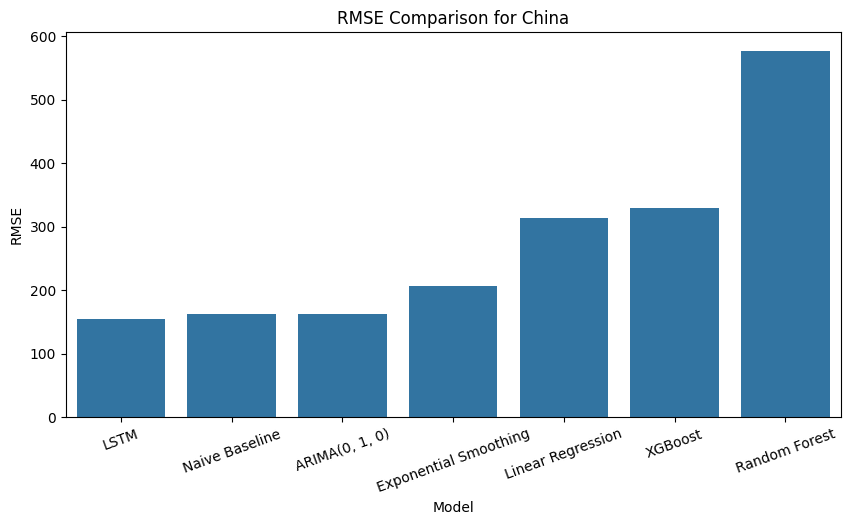

In [44]:
# %%
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df.sort_values('RMSE'), x='Model', y='RMSE')
plt.title(f"RMSE Comparison for {selected_country}")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

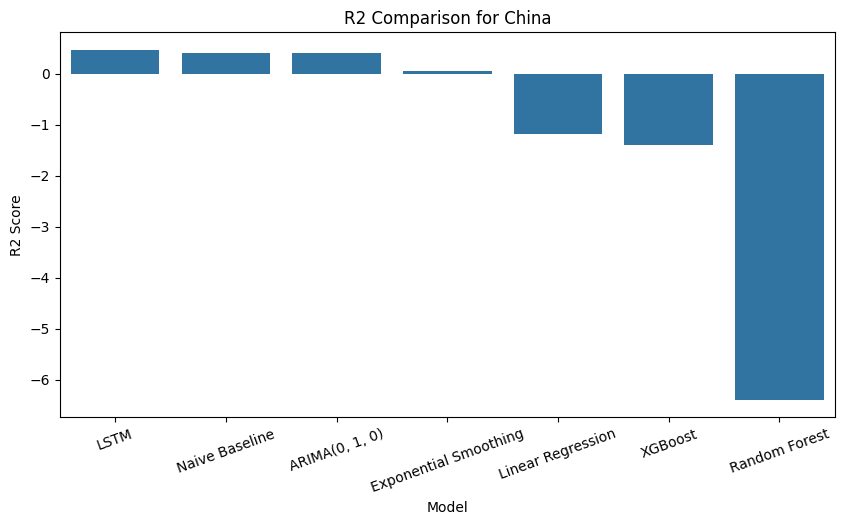

In [45]:
# %%
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df.sort_values('R2', ascending=False), x='Model', y='R2')
plt.title(f"R2 Comparison for {selected_country}")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

In [46]:
# %%
best_model_row = metrics_df.sort_values('RMSE').iloc[0]
print("\nBest model based on RMSE:")
print(best_model_row)


Best model based on RMSE:
Model         LSTM
MAE      132.61675
MSE       0.000442
RMSE     154.94577
R2        0.466711
Name: 6, dtype: object
